<a href="https://colab.research.google.com/github/yahelmenahem/yahel/blob/main/part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# חלק 1 : רגרסיה

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving auto+mpg.zip to auto+mpg.zip


# זיהוי ערכים חסרים

In [ ]:
import pandas as pd
import zipfile
# הגדרת שמות העמודות לפי התיעוד [cite: 2051, 2052]
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

# טעינת הנתונים מתוך ה-ZIP והחלפת '?' ב-NaN
with zipfile.ZipFile('auto+mpg.zip', 'r') as z:
    with z.open('auto-mpg.data') as f:
        df = pd.read_csv(f, sep='\s+', names=column_names, na_values='?')

# הצגת כמות הערכים החסרים בכל עמודה
print("Missing values per feature:")
print(df.isnull().sum())

Missing values per feature:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_169/2345570206.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(f, sep='\s+', names=column_names, na_values='?')


# התפלגות משתנה המטרה

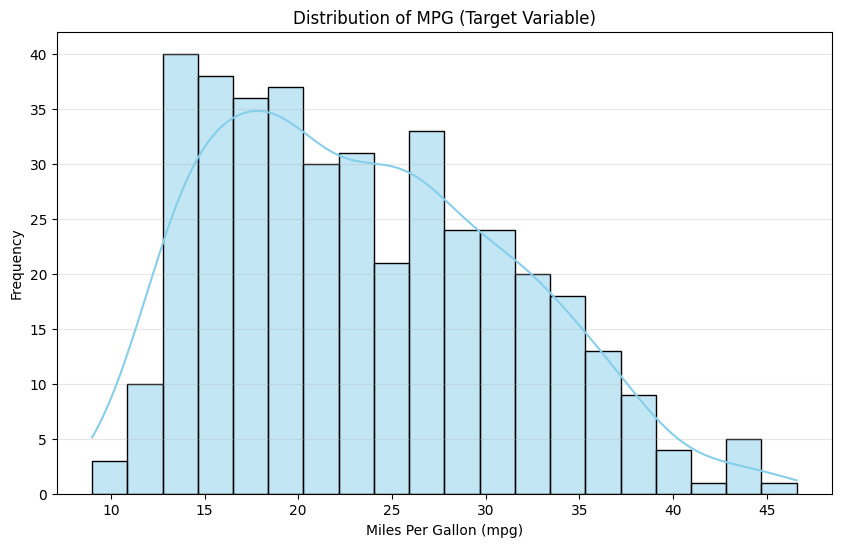

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['mpg'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of MPG (Target Variable)')
plt.xlabel('Miles Per Gallon (mpg)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# קשר בין המאפיינים למשתנה המטרה

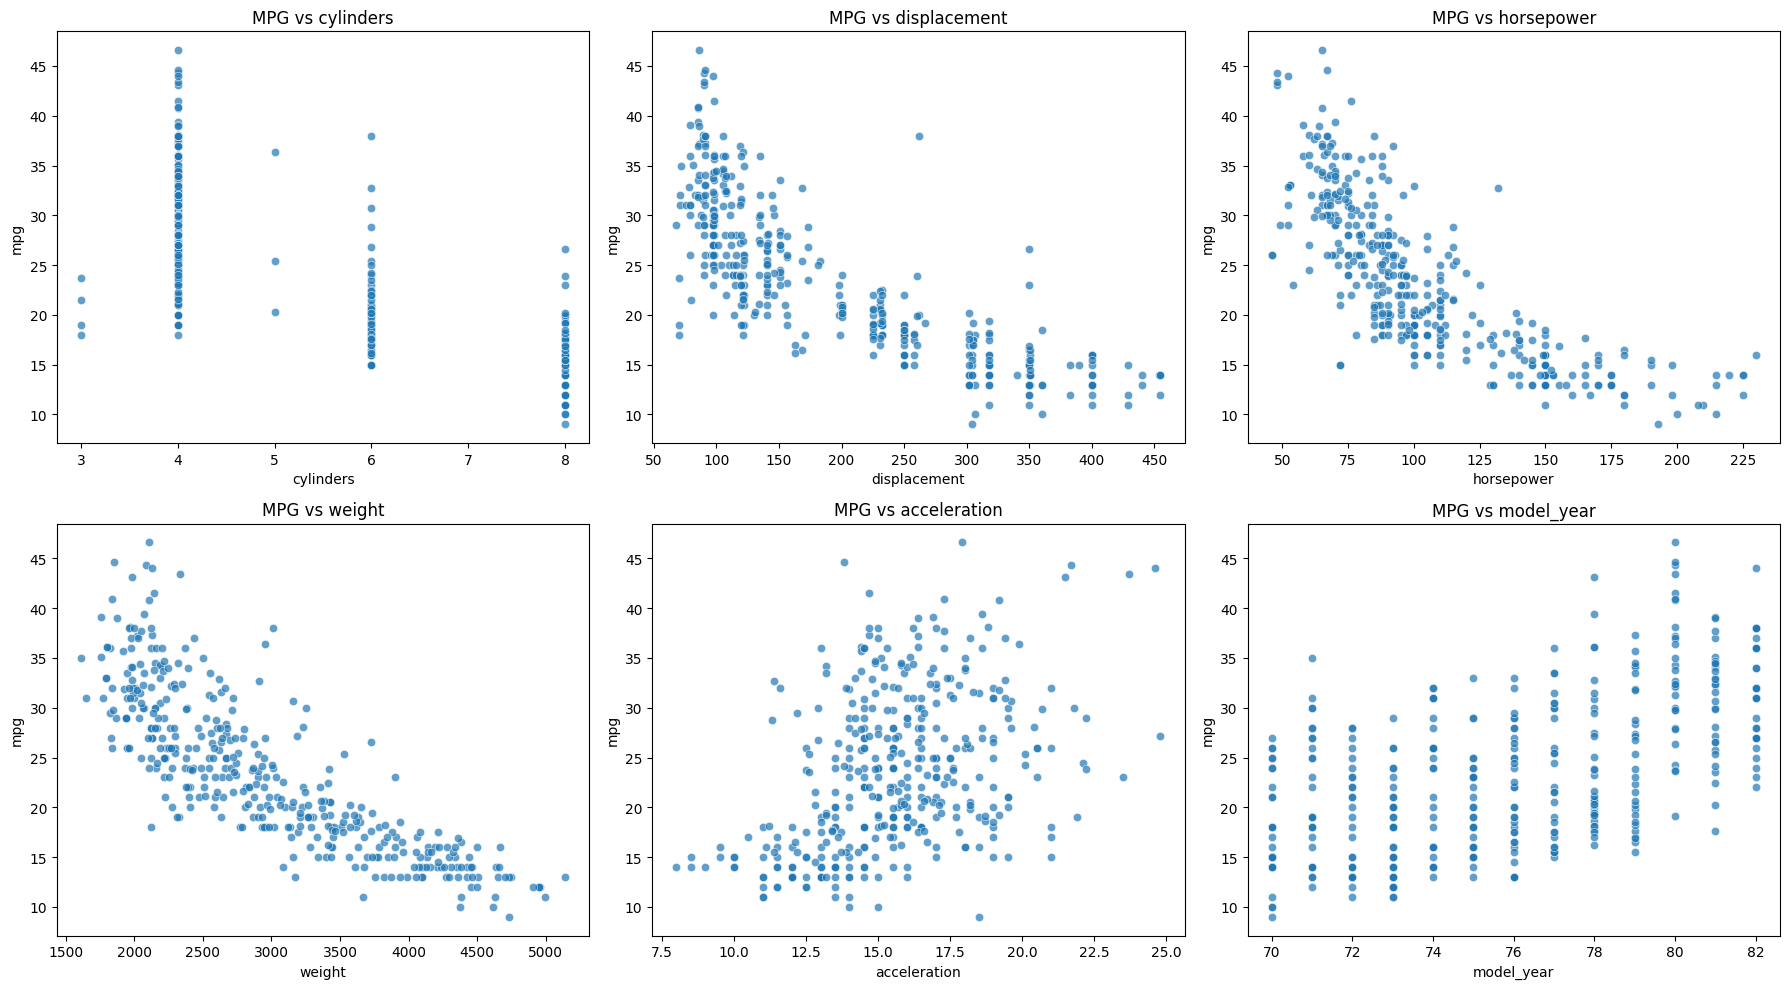

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# רשימת מאפיינים מספריים לניתוח (מתוך המאפיינים הזמינים בדאטה) [cite: 9, 316]
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    # יצירת גרף פיזור עבור כל מאפיין מול משתנה המטרה mpg [cite: 326]
    sns.scatterplot(data=df, x=feature, y='mpg', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'MPG vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('mpg')

plt.tight_layout()
plt.show()

# מתאמים בין המאפיינים

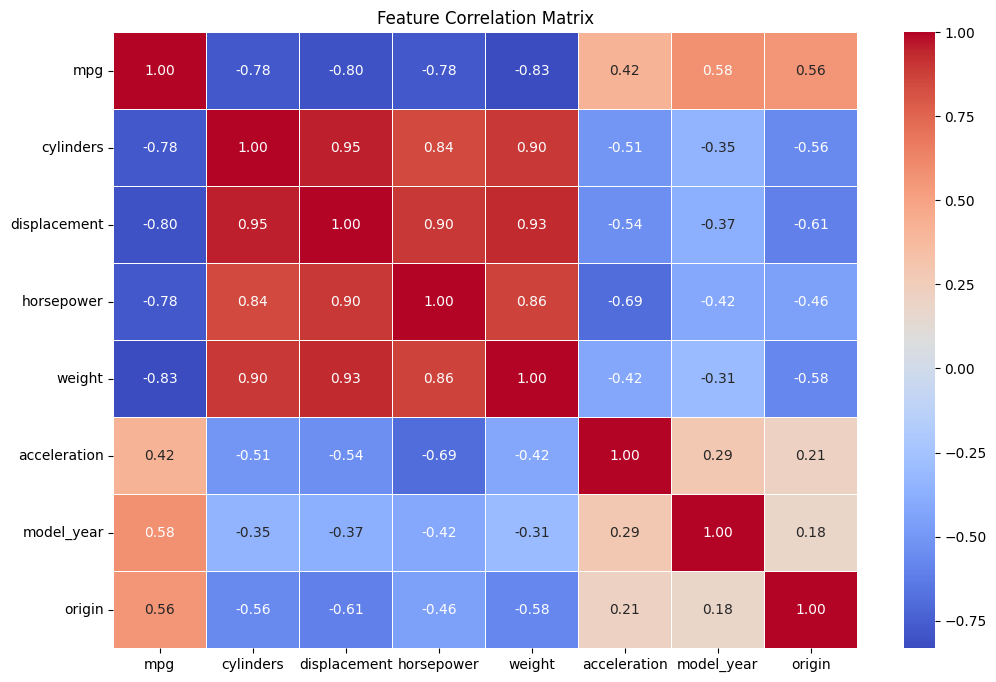

In [ ]:
plt.figure(figsize=(12, 8))
# הסרת עמודת car_name שהיא מחרוזת
correlation_matrix = df.drop('car_name', axis=1).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# טיפול בערכים החסרים ובחירת מאפיינים

In [ ]:
# הסרת שורות עם ערכים חסרים (NaN) בעמודת horsepower
# מומלץ להסיר אותן מכיוון שמדובר בכמות קטנה מאוד של דגימות (6 מתוך 398) [cite: 8, 10]
df_clean = df.dropna(subset=['horsepower'])

# בחירת המאפיינים (Features) ומשתנה המטרה (Target) [cite: 314, 316]
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
X = df_clean[features]
y = df_clean['mpg']

print(f"Original instances: {len(df)}")
print(f"Instances after removing missing values: {len(df_clean)}")

Original instances: 398
Instances after removing missing values: 392


# פיצול הנתונים ל train , test and validation

In [ ]:
from sklearn.model_selection import train_test_split

# פיצול ראשון: 85% אימון+ולידציה, 15% בדיקה (Test) [cite: 369]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# פיצול שני: חלוקת ה-85% ל-70% אימון ו-15% ולידציה [cite: 347]
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.176, random_state=42)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 274, Validation size: 59, Test size: 59


# נרמול

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# התאמה וטרנספורמציה על נתוני האימון
X_train_scaled = scaler.fit_transform(X_train)

# טרנספורמציה בלבד על נתוני הולידציה והבדיקה (למניעת זליגת מידע)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardization complete.")

Standardization complete.


# **אימון מודל רגרסיה לנארית**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# בניית ואימון המודל
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# חיזוי על סט הולידציה
y_val_pred = lr.predict(X_val_scaled)

# חישוב המדדים (שים לב לתיקון בשם המשתנה בשורת ה-MAE)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_val_pred) # תוקן מ-y_pred_val ל-y_val_pred
r2 = r2_score(y_val, y_val_pred)

print(f"Validation Metrics for Linear Regression:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Validation Metrics for Linear Regression:
MSE: 12.6652
RMSE: 3.5588
MAE: 2.7619
R^2 Score: 0.7866


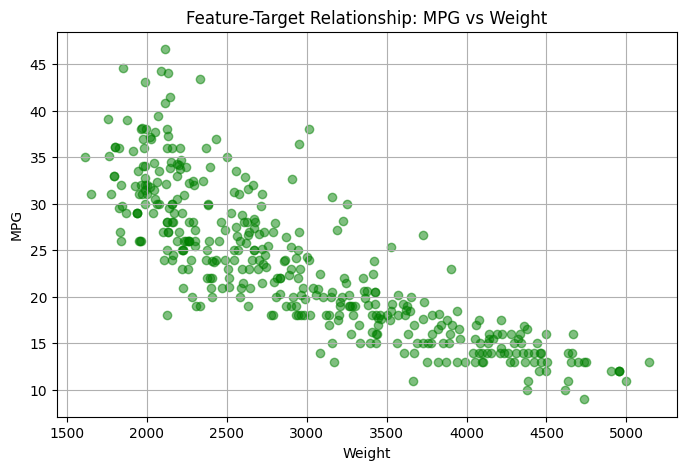

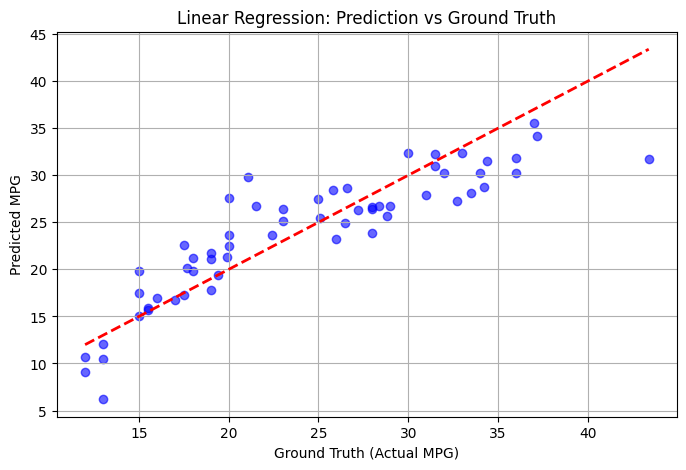

In [ ]:
import matplotlib.pyplot as plt

# גרף 1: הקשר בין המשקל (Weight) לצריכת הדלק (MPG) [cite: 326]
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['weight'], df_clean['mpg'], alpha=0.5, color='green')
plt.title('Feature-Target Relationship: MPG vs Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

# גרף 2: חיזוי מול ערכי אמת [cite: 327]
plt.figure(figsize=(8, 5))
plt.scatter(y_val, y_val_pred, alpha=0.6, color='blue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Linear Regression: Prediction vs Ground Truth')
plt.xlabel('Ground Truth (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

# **רגרסיה פולינומיאלית**

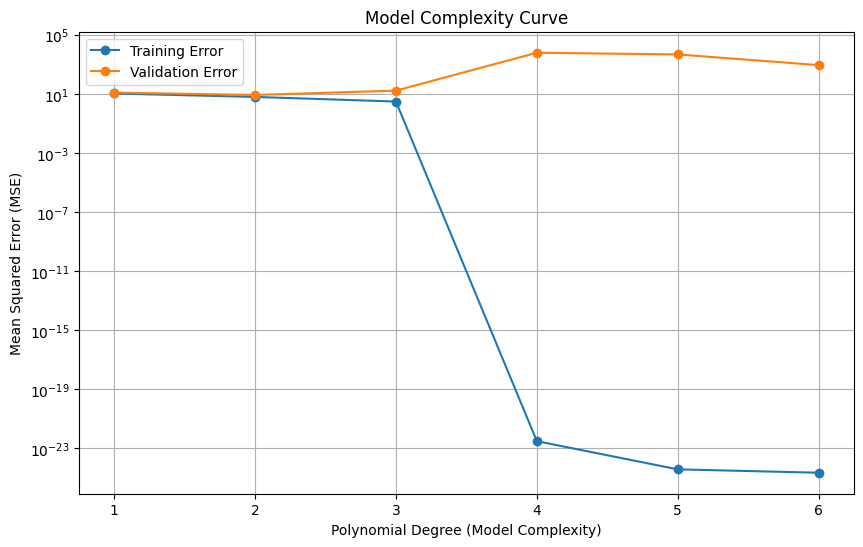

The optimal polynomial degree is: 2


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1, 7) # בדיקת דרגות מ-1 עד 6
train_losses = []
val_losses = []

for d in degrees:
    # יצירת מאפיינים פולינומיים
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    # אימון
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # חישוב שגיאת MSE [cite: 338]
    train_losses.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_losses.append(mean_squared_error(y_val, model.predict(X_val_poly)))

# הצגת עקומת המורכבות [cite: 338]
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_losses, label='Training Error', marker='o')
plt.plot(degrees, val_losses, label='Validation Error', marker='o')
plt.yscale('log') # סקאלה לוגריתמית עוזרת לראות Overfitting חריף בדרגות גבוהות
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Model Complexity Curve')
plt.legend()
plt.grid(True)
plt.show()

# בחירת הדרגה האופטימלית (המינימום בולידציה) [cite: 342]
best_d = degrees[np.argmin(val_losses)]
print(f"The optimal polynomial degree is: {best_d}")

# KNN

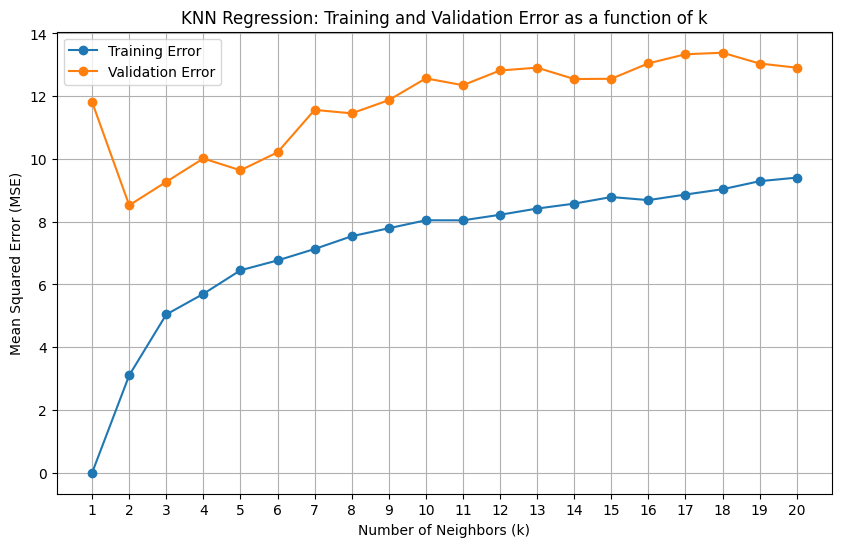

The best value for k based on validation performance is: 2


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# הגדרת טווח ערכי k לבדיקה
k_values = range(1, 21)
knn_train_errors = []
knn_val_errors = []

for k in k_values:
    # יצירת המודל ואימונו
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # חישוב שגיאות MSE עבור אימון וולידציה
    knn_train_errors.append(mean_squared_error(y_train, knn.predict(X_train_scaled)))
    knn_val_errors.append(mean_squared_error(y_val, knn.predict(X_val_scaled)))

# גרף שגיאת אימון וולידציה כפונקציה של k
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_train_errors, label='Training Error', marker='o')
plt.plot(k_values, knn_val_errors, label='Validation Error', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('KNN Regression: Training and Validation Error as a function of k')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# בחירת ה-k הטוב ביותר לפי ביצועי הולידציה
best_k = k_values[np.argmin(knn_val_errors)]
print(f"The best value for k based on validation performance is: {best_k}")

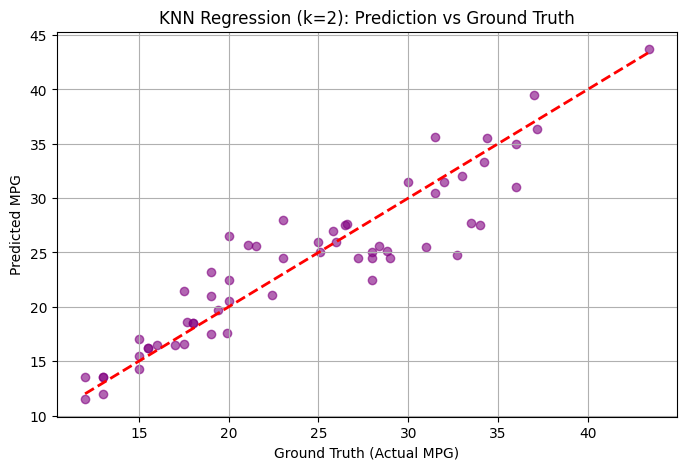

KNN Validation MSE (k=2): 8.5241


In [ ]:
# אימון מודל סופי עם ה-k שנבחר
best_knn_model = KNeighborsRegressor(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)

# חיזוי על סט הולידציה
y_val_pred_knn = best_knn_model.predict(X_val_scaled)

# גרף חיזוי מול ערכי אמת עבור KNN
plt.figure(figsize=(8, 5))
plt.scatter(y_val, y_val_pred_knn, alpha=0.6, color='purple')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title(f'KNN Regression (k={best_k}): Prediction vs Ground Truth')
plt.xlabel('Ground Truth (Actual MPG)')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

# דיווח מדדים לולידציה
knn_mse = mean_squared_error(y_val, y_val_pred_knn)
print(f"KNN Validation MSE (k={best_k}): {knn_mse:.4f}")

# השוואת BGD עם MBGD

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

def train_with_optimization(X_tr, y_tr, X_v, y_v, batch_size, epochs=100, lr=0.01):
    model = SGDRegressor(learning_rate='constant', eta0=lr, random_state=42)
    train_losses = []
    val_losses = []

    n_samples = X_tr.shape[0]

    for epoch in range(epochs):
        # ערבוב הנתונים בכל epoch
        indices = np.random.permutation(n_samples)
        X_tr_shuffled = X_tr[indices]
        y_tr_shuffled = y_tr.iloc[indices]

        # חלוקה ל-batches
        for i in range(0, n_samples, batch_size):
            X_batch = X_tr_shuffled[i:i+batch_size]
            y_batch = y_tr_shuffled[i:i+batch_size]
            model.partial_fit(X_batch, y_batch)

        # תיעוד השגיאה בסוף כל epoch
        train_losses.append(mean_squared_error(y_tr, model.predict(X_tr)))
        val_losses.append(mean_squared_error(y_v, model.predict(X_v)))

    return train_losses, val_losses

print("Optimization functions defined.")

Optimization functions defined.


In [ ]:
# הגדרות משותפות
n_epochs = 100
learning_rate = 0.001

# 1. Batch Gradient Descent (Batch size = Total training samples)
batch_size_full = X_train_scaled.shape[0]
batch_train_loss, batch_val_loss = train_with_optimization(
    X_train_scaled, y_train, X_val_scaled, y_val,
    batch_size=batch_size_full, epochs=n_epochs, lr=learning_rate
)

# 2. Mini-batch Gradient Descent (Batch size = 32)
batch_size_mini = 32
mini_train_loss, mini_val_loss = train_with_optimization(
    X_train_scaled, y_train, X_val_scaled, y_val,
    batch_size=batch_size_mini, epochs=n_epochs, lr=learning_rate
)

print("Training with both optimization settings complete.")

Training with both optimization settings complete.


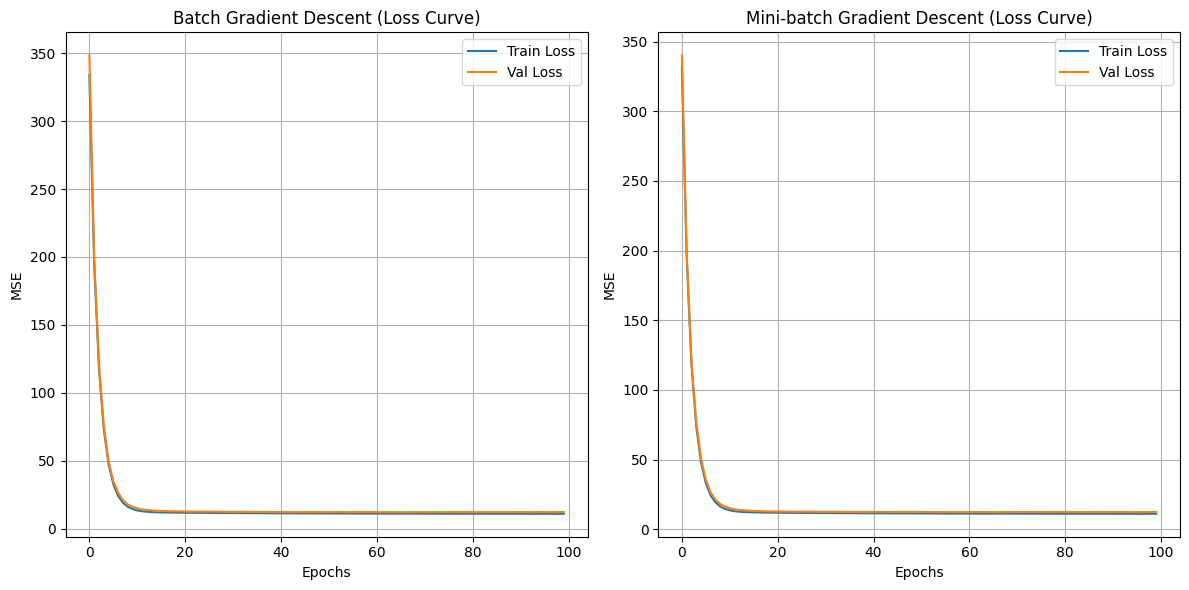

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# גרף עבור Batch GD
plt.subplot(1, 2, 1)
plt.plot(range(n_epochs), batch_train_loss, label='Train Loss')
plt.plot(range(n_epochs), batch_val_loss, label='Val Loss')
plt.title('Batch Gradient Descent (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# גרף עבור Mini-batch GD
plt.subplot(1, 2, 2)
plt.plot(range(n_epochs), mini_train_loss, label='Train Loss')
plt.plot(range(n_epochs), mini_val_loss, label='Val Loss')
plt.title('Mini-batch Gradient Descent (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# השוואת מודלים

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

# 1. חישוב מדדים לרגרסיה ליניארית (כבר קיים, אך נרכז)
y_val_pred_lr = lr.predict(X_val_scaled)
lr_mse = mean_squared_error(y_val, y_val_pred_lr)
lr_r2 = r2_score(y_val, y_val_pred_lr)

# 2. חישוב מדדים לרגרסיה פולינומית (בדרגה הטובה ביותר שמצאנו - best_d)
poly_best = PolynomialFeatures(degree=best_d)
X_train_poly_best = poly_best.fit_transform(X_train_scaled)
X_val_poly_best = poly_best.transform(X_val_scaled)
model_poly = LinearRegression().fit(X_train_poly_best, y_train)

y_val_pred_poly = model_poly.predict(X_val_poly_best)
poly_mse = mean_squared_error(y_val, y_val_pred_poly)
poly_r2 = r2_score(y_val, y_val_pred_poly)

# 3. חישוב מדדים ל-KNN (ב-best_k שמצאנו)
# הערה: best_knn_model כבר מאומן משלב 8
y_val_pred_knn = best_knn_model.predict(X_val_scaled)
knn_mse = mean_squared_error(y_val, y_val_pred_knn)
knn_r2 = r2_score(y_val, y_val_pred_knn)

# יצירת טבלת השוואה
comparison_data = {
    'Model': ['Linear Regression', f'Polynomial (Degree {best_d})', f'KNN (k={best_k})'],
    'Validation MSE': [lr_mse, poly_mse, knn_mse],
    'Validation R^2': [lr_r2, poly_r2, knn_r2],
    'Interpretability': ['High', 'Medium', 'Low'],
    'Bias-Variance': ['High Bias / Low Variance', 'Balanced', 'Low Bias / Potential High Variance']
}

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison Table (Validation Set):")
display(comparison_df)

Model Comparison Table (Validation Set):


,Model,Validation MSE,Validation R^2,Interpretability,Bias-Variance
0,Linear Regression,12.665154,0.786615,High,High Bias / Low Variance
1,Polynomial (Degree 2),8.732708,0.852870,Medium,Balanced
2,KNN (k=2),8.524068,0.856385,Low,Low Bias / Potential High Variance


In [ ]:
# זיהוי המודל המנצח אוטומטית לפי ה-MSE הנמוך ביותר
best_model_name = comparison_df.loc[comparison_df['Validation MSE'].idxmin(), 'Model']
print(f"Final Chosen Model: {best_model_name}")

# הערכה על סט המבחן (Test Set)
# בדוגמה זו נבצע הערכה עבור המודל הפולינומיאלי (אם הוא נבחר)
# אם KNN נבחר, נשתמש ב-best_knn_model.predict(X_test_scaled)

if 'Polynomial' in best_model_name:
    X_test_poly = poly_best.transform(X_test_scaled)
    y_test_pred = model_poly.predict(X_test_poly)
elif 'KNN' in best_model_name:
    y_test_pred = best_knn_model.predict(X_test_scaled)
else:
    y_test_pred = lr.predict(X_test_scaled)

# דיווח מדדים סופיים על סט המבחן
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n--- Final Performance on Test Set ({best_model_name}) ---")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R^2: {test_r2:.4f}")

Final Chosen Model: KNN (k=2)

--- Final Performance on Test Set (KNN (k=2)) ---
Test MSE: 6.8163
Test RMSE: 2.6108
Test MAE: 1.7305
Test R^2: 0.8835
